# NASDAQ-100 Microstructure - Order Flow: Causal DML Estimation

Does signed volume share *cause* future 15-minute returns, or is the observed
price impact already accounted for by spread and volatility? This notebook
applies double machine learning (DML) to `signed_vol_share` across NASDAQ-100
stocks on a one-minute observation grid.

DML separates a treatment effect from confounding in two stages. The first
stage predicts the outcome from the confounders, and separately predicts the
treatment from the same confounders, using cross-fitting so no observation
helps predict itself. The second stage regresses the outcome residual on the
treatment residual, which measures the part of the treatment the confounders
do not explain. That remainder is the quantity a causal claim needs.

**The treatment** is signed volume share: the fraction of a bar's traded
volume classified as buyer-initiated by the Lee-Ready rule, which assigns a
trade to the buyer when it prints above the prevailing quote midpoint. **The
confounders** are the relative bid-ask spread at the close of the bar, which
stands for how costly the name is to trade; five-minute realized volatility,
which stands for how noisy it currently is; and the trailing one-month
cumulative return, which stands for slower drift the bar inherits.

**Learning Objectives**:
- Estimate a treatment effect on a panel where the label horizon is longer
  than the observation grid, so consecutive labels overlap
- Set the cross-fitting gap and the permutation block length from that label
  horizon rather than from the bar size
- Read a permutation refutation test alongside a parametric standard error,
  and say what each one can and cannot establish

**Book Reference**: Chapter 15, Section 15.6 (Cross-Dataset Causal Evidence)

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb),
[`04_model_based_features`](04_model_based_features.ipynb)

## Identifying Assumptions

DML estimates a causal effect under three assumptions:
1. **Conditional ignorability**: No unobserved confounders — all backdoor paths
   between treatment and outcome are blocked by the observed confounders.
2. **Overlap (positivity)**: Every unit has a nonzero probability of receiving
   any treatment level, conditional on confounders.
3. **SUTVA**: One unit's treatment doesn't affect another's outcome.

These are untestable. The refutation test below provides indirect evidence
but cannot prove the assumptions hold.

In [1]:
"""Causal DML - walk-forward estimation with refutation tests."""

import warnings
from datetime import timedelta

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import yaml

from case_studies.utils.causal import (
    classify_refutation,
    format_dml_summary,
    register_causal_run,
    run_dml_analysis,
)
from utils.artifact_specs import resolve_label_horizon
from utils.modeling import load_configs, load_modeling_dataset
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds

warnings.filterwarnings("ignore")

### Settings

`MAX_SAMPLES` decides what population the effect is a statement about. Zero
estimates on the whole pre-holdout sample. A positive value keeps only that
many of the most recent rows, which narrows the claim to that window: on a
one-minute panel of about 115 names, 50,000 rows is a little over one trading
day. Either way the value is recorded with the run, so a capped estimate and a
full one are never confused for each other.

`CV_FOLDS` sets how many expanding train-and-predict blocks the cross-fitting
uses, and `N_PLACEBO` how many shuffled replications the refutation test draws.
The permutation p-value cannot resolve finer than one part in `N_PLACEBO`.

In [2]:
CASE_STUDY_ID = "nasdaq100_microstructure"
PRIMARY_LABEL = ""
MAX_SYMBOLS = 0
RANDOM_SEED = 42
CV_FOLDS = 5
MAX_SAMPLES = 0
N_PLACEBO = 100

In [ ]:
set_global_seeds(RANDOM_SEED)
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)

# Resolve label from setup.yaml if not overridden
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
if not PRIMARY_LABEL:
    PRIMARY_LABEL = setup["labels"]["primary"]

# Load DML config and apply Papermill overrides
causal_configs = load_configs(CASE_STUDY_ID, PRIMARY_LABEL, "causal_dml")
dml_cfg = causal_configs[0]

for key, val in [
    ("n_folds", CV_FOLDS),
    ("n_placebo", N_PLACEBO),
    ("max_samples", MAX_SAMPLES),
    ("seed", RANDOM_SEED),
]:
    if dml_cfg.get(key, val) != val:
        dml_cfg[key] = val

CV_FOLDS = dml_cfg.get("n_folds", 5)
N_PLACEBO = dml_cfg.get("n_placebo", 100)
MAX_SAMPLES = dml_cfg.get("max_samples", 50000)
RANDOM_SEED = dml_cfg.get("seed", 42)

print(f"DML config: {dml_cfg['config_name']}")

# Read causal config from setup.yaml
causal_cfg = setup.get("causal", {})
TREATMENT_COL = causal_cfg.get("treatment", "")
CONFOUNDER_COLS = causal_cfg.get("confounders", [])
DML_METHOD = causal_cfg.get("method", "walk_forward_dml")

if not TREATMENT_COL:
    raise ValueError(
        f"No causal.treatment in {CASE_STUDY_ID}/setup.yaml. "
        "Add a 'causal:' section with treatment and confounders."
    )

np.random.seed(RANDOM_SEED)

print("Causal DML Configuration:")
print(f"  Case study: {CASE_STUDY_ID}")
print(f"  Treatment: {TREATMENT_COL}")
print(f"  Outcome: {PRIMARY_LABEL}")
print(f"  Confounders: {CONFOUNDER_COLS}")
print(f"  CV folds: {CV_FOLDS}")
print(f"  Placebo reps: {N_PLACEBO}")

## 1. Load Artifacts

Load pre-computed features, temporal features, and labels using the
shared modeling infrastructure.

In [4]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)

dataset = mds.dataset
feature_names = mds.feature_names
label_col = mds.label_col
date_col = mds.date_col
entity_cols = mds.entity_cols

# The estimand is defined by the treatment and the full confounder set. Estimating
# without one of them answers a different question, so a missing column stops the
# run rather than quietly shrinking the adjustment set.
analysis_cols = list(dict.fromkeys([date_col, *entity_cols, TREATMENT_COL, label_col]))
analysis_cols += [c for c in CONFOUNDER_COLS if c not in analysis_cols]

missing = sorted(set(analysis_cols) - set(dataset.columns))
if missing:
    raise ValueError(
        f"{CASE_STUDY_ID} declares causal columns that the finalized feature "
        f"artifact does not contain: {missing}. Reconcile config/setup.yaml with "
        f"03_financial_features before estimating."
    )

print(f"\nDataset: {len(dataset):,} rows x {len(feature_names)} features")
print(f"Label: {label_col} | Date: {date_col} | Entities: {entity_cols}")


Dataset: 13,014,720 rows x 88 features
Label: fwd_ret_15m | Date: timestamp | Entities: ['symbol']


## 2. Size the temporal geometry from the label horizon

The label looks forward 15 minutes while the panel is observed once a minute,
so a row's outcome overlaps the next fourteen rows' outcomes. Two settings have
to be sized against that overlap rather than against the bar:

- The **embargo** is the gap left between a training block and the validation
  block that follows it. If it is shorter than the label horizon, the last
  training rows resolve inside the validation window and the fit has seen part
  of what it is scored on.
- The **permutation block length** is how many consecutive decision times move
  together when the refutation test shuffles the treatment. Blocks shorter than
  the overlap leave the dependence in place and the test reports a narrower
  placebo distribution than the data supports.

Both are counted in observation periods, so the notebook measures the grid step
from the data rather than assuming it. The measurement is not a formality here:
`decision.bar_frequency` in `setup.yaml` says fifteen minutes, and that is how
often the strategy acts, not how far apart the observations are. Dividing the
label horizon by it would give one period instead of fifteen, and the result
would look entirely normal.

In [5]:
grid = dataset.select(pl.col(date_col).unique().sort().alias("t"))
step_counts = grid.select(pl.col("t").diff().alias("d")).drop_nulls().group_by("d").len()
GRID_STEP = step_counts.sort("len", descending=True)["d"][0]

LABEL_HORIZON = pd.Timedelta(resolve_label_horizon(CASE_STUDY_ID, PRIMARY_LABEL, setup))
HORIZON_PERIODS = int(LABEL_HORIZON // pd.Timedelta(GRID_STEP))
if HORIZON_PERIODS < 1:
    raise ValueError(
        f"Label horizon {LABEL_HORIZON} is shorter than the {GRID_STEP} observation grid"
    )

EMBARGO_PERIODS = HORIZON_PERIODS
BLOCK_SIZE = HORIZON_PERIODS

print(f"Observation grid: {GRID_STEP} | label horizon: {LABEL_HORIZON}")
print(f"Horizon in periods: {HORIZON_PERIODS}")
print(f"Embargo: {EMBARGO_PERIODS} periods | permutation block: {BLOCK_SIZE} periods")

Taking most recent 50,000 from 13,014,720


## 3. Seal the holdout and keep whole decision panels

Estimation reads only dates before `evaluation.holdout_start`, and stops one
label horizon earlier still: a bar timestamped just before the boundary
resolves after it, so keeping it would let the held-out period influence the
estimate through the label.

The sample cap then takes the most recent complete decision times that fit in
the row budget, so each decision time is either kept whole or dropped whole.
That keeps every statistic grouped by decision time computed on a full
cross-section.

In [6]:
HOLDOUT_START = pd.Timestamp(setup["evaluation"]["holdout_start"])
ESTIMATION_END = HOLDOUT_START - LABEL_HORIZON


def whole_panel_tail(frame: pl.DataFrame, timestamp: str, max_rows: int) -> pl.DataFrame:
    """Most recent complete decision panels that fit inside ``max_rows``."""
    if max_rows <= 0 or frame.height <= max_rows:
        return frame
    counts = frame.group_by(timestamp).len().sort(timestamp)
    counts = counts.with_columns(pl.col("len").reverse().cum_sum().reverse().alias("suffix_n"))
    keep = counts.filter(pl.col("suffix_n") <= max_rows).select(timestamp)
    if keep.is_empty():
        raise ValueError(
            f"MAX_SAMPLES={max_rows} is smaller than one decision panel; raise it "
            f"above the {counts['len'].max()} symbols quoting at a single timestamp"
        )
    return frame.join(keep, on=timestamp, how="semi")


analysis = (
    dataset.select(analysis_cols)
    .drop_nulls()
    .filter(pl.col(date_col) < pl.lit(ESTIMATION_END))
    .sort([date_col, entity_cols[0]])
)
analysis = whole_panel_tail(analysis, date_col, MAX_SAMPLES)

observed_end = analysis[date_col].max()
if observed_end is None or pd.Timestamp(observed_end) + LABEL_HORIZON > HOLDOUT_START:
    raise AssertionError(
        f"A DML label endpoint reaches the holdout: last decision time "
        f"{observed_end} resolves at or after {HOLDOUT_START}"
    )

merged_clean = analysis.to_pandas()


Analysis data: 50,000 rows
Date range: 2021-12-30 11:35:00 to 2021-12-31 15:44:00
Embargo: 1 periods | Block size: 1
Entities: 99


In [ ]:
panel_sizes = analysis.group_by(date_col).len()["len"]
print(f"Analysis data: {len(merged_clean):,} rows over {analysis[date_col].n_unique():,} times")
print(f"Date range: {merged_clean[date_col].min()} to {merged_clean[date_col].max()}")
print(f"Holdout opens {HOLDOUT_START.date()}; estimation stops by {ESTIMATION_END}")
print(f"Panel size: {panel_sizes.min()}-{panel_sizes.max()} symbols per decision time")

## 4. Run DML Analysis

Three steps run together: a naive ordinary least squares baseline that ignores
confounding, the cross-fitted DML estimate with the embargo above, and the
block permutation refutation test.

The second stage reports a Newey-West standard error, which widens the interval
to account for observations whose errors are correlated in time. Passing the
label horizon sets how many lags it accounts for. Left to infer, it falls back
to a rule based only on sample size, which under-lags an overlapping label and
reports a t-statistic that is too large.

In [7]:
results = run_dml_analysis(
    merged_clean,
    treatment_col=TREATMENT_COL,
    outcome_col=label_col,
    confounder_cols=CONFOUNDER_COLS,
    n_folds=CV_FOLDS,
    embargo=EMBARGO_PERIODS,
    n_placebo=N_PLACEBO,
    block_size=BLOCK_SIZE,
    seed=RANDOM_SEED,
    horizon=HORIZON_PERIODS,
    time_col=date_col,
    entity_col=entity_cols[0],
)

print(format_dml_summary(results))

DML ANALYSIS SUMMARY
Observations: 50,000
HAC bandwidth: 34 lags (cube-root rule)

Naive OLS effect:  0.000001
DML effect:        0.000001
  SE (IID):        0.000000
  SE (HAC):        0.000000
  t-stat (HAC):    2.52
  p-value (HAC):   0.0118

Confounding bias:  -0.000000 (-9.9%)

Refutation (block permutation):
  Z-score:      1.57
  Empirical p:  0.1100
  Classification: Fails
  Placebos:     100


## 5. Statistical Assessment

Two quantities describe how far adjustment moved the answer and how much of the
remaining effect could be an artifact of the panel's time structure.

Confounding bias compares the unadjusted slope with the adjusted one, scaled by
the adjusted effect so it reads as a percentage:

$$\text{Bias \%} = \frac{\hat{\theta}_{\text{naive}} - \hat{\theta}_{\text{DML}}}{|\hat{\theta}_{\text{DML}}|} \times 100$$

A positive value means the raw association overstates the effect and the
confounders were carrying part of it. A value near zero means the treatment was
already close to orthogonal to them, which is common at intraday frequency
where spread and volatility move on their own schedule.

The two significance readings answer different questions and can disagree. The
Newey-West p-value asks whether the effect is distinguishable from zero under a
parametric model of the errors. The permutation p-value asks how often the same
estimator recovers an effect this large from data whose treatment has been
shuffled in blocks, which keeps the panel's shape but destroys the treatment's
alignment with the outcome. When the permutation test does not corroborate the
parametric one, the parametric standard error is the reading to distrust: it
rests on an assumption about the errors that the shuffle does not need.

In [8]:
dml_result = results["dml_result"]
naive_effect = results["naive_effect"]
dml_effect = dml_result["theta"]
se_hac = dml_result["se_hac"]
bias_pct = results["confounding_bias_pct"]

# p-value computed in run_dml_analysis (no duplication)
p_value = results["p_value_hac"]

ref = results.get("refutation", {})
p_value_perm = ref.get("empirical_p", 1.0)
ref_class = ref.get("refutation_class", classify_refutation(p_value_perm))

print("Statistical significance:")
print(f"  p-value (HAC): {p_value:.4f}")
print(f"  Significant at 5%: {'Yes' if p_value < 0.05 else 'No'}")
if ref:
    print(f"  Refutation: {ref_class} (p={p_value_perm:.4f})")

Statistical significance:
  p-value (HAC): 0.0118
  Significant at 5%: Yes
  Refutation: Fails (p=0.1100)


> **When should you be suspicious of large DML corrections?** A naive-to-DML
> amplification exceeding 5x warrants scrutiny. Possible causes:
> (1) nuisance models overfitting and stripping outcome-relevant variation,
> (2) weak instrument-like behavior where the treatment residual has low variance,
> (3) genuine massive confounding that naive OLS entirely misses.
> The refutation test helps distinguish (3) from (1-2): if placebos also show
> inflated effects, the DML correction may be unreliable.

### Permutation Distribution

The observed DML effect (red line) against the distribution of placebo
effects under block permutation of the treatment.

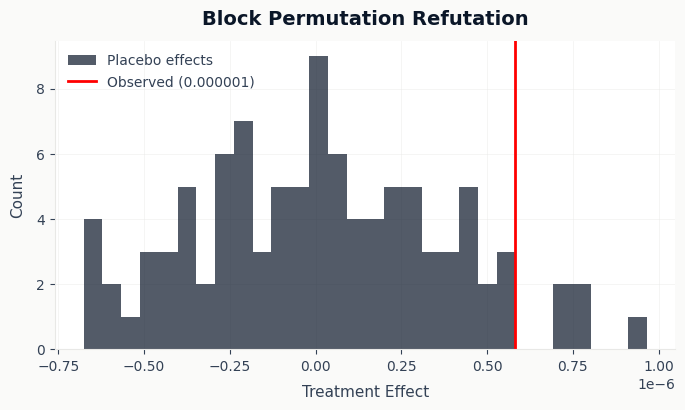

In [9]:
placebo_arr = np.array(ref.get("placebo_effects", []))
if len(placebo_arr) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(placebo_arr, bins=30, alpha=0.7, label="Placebo effects")
    ax.axvline(dml_effect, color="red", linewidth=2, label="Observed effect")
    ax.set_xlabel("Treatment effect")
    ax.set_ylabel("Placebo replications")
    ax.set_title("Observed effect against its block-permutation placebos")
    ax.legend()

## 6. Register the run

Cross-fitting leaves one treatment residual and one outcome residual per row,
both carrying the entity and decision time they were computed for. The
registered run records the estimate together with the settings that produced
it, so a later reader can tell two runs apart by their configuration rather
than by when they happened.

Cross-fitting returns one treatment residual and one outcome residual per
analysis row, in that frame's order, with training-only rows left empty. The
check below requires that correspondence to hold exactly: a mismatch means the
residuals and the rows describe different observations, and pairing them by
position would bury that rather than surface it.

In [10]:
T_res = dml_result["T_res"]
Y_res = dml_result["Y_res"]
if len(T_res) != len(merged_clean) or len(Y_res) != len(merged_clean):
    raise AssertionError(
        f"DML returned {len(T_res)} treatment and {len(Y_res)} outcome residuals "
        f"for {len(merged_clean)} analysis rows; the residuals are not keyed to "
        f"the estimation frame"
    )

register_causal_run(
    case_study_id=CASE_STUDY_ID,
    label=PRIMARY_LABEL,
    results=results,
    treatment_col=TREATMENT_COL,
    confounder_cols=CONFOUNDER_COLS,
    n_folds=CV_FOLDS,
    embargo=EMBARGO_PERIODS,
    time_col=date_col,
    block_size=BLOCK_SIZE,
    n_placebo=N_PLACEBO,
    seed=RANDOM_SEED,
    horizon=HORIZON_PERIODS,
    max_samples=MAX_SAMPLES,
    development_end=str(ESTIMATION_END),
    notebook="12_causal_dml",
)

  -> registered causal_dml (causal_hash=5615816d640e, p_hac=0.0118)


'5615816d640e'

### What this run estimated

In [11]:
print(f"Treatment: {TREATMENT_COL} -> {label_col}")
print(f"Confounders: {', '.join(CONFOUNDER_COLS)}")
print(f"Observations entering the second stage: {dml_result['n_obs']:,}")
print(f"Naive slope: {naive_effect:+.3e}")
print(f"Adjusted (DML) slope: {dml_effect:+.3e}  (Newey-West SE {se_hac:.3e})")
print(f"Confounding bias: {bias_pct:+.1f}%")
print(f"Newey-West p-value: {p_value:.4f}  (lags {results.get('hac_maxlags', 0)})")
print(f"Permutation p-value: {p_value_perm:.4f}  ({ref_class})")


CHAPTER 15 RESULTS: nasdaq100_microstructure causal DML
  treatment: signed_vol_share
  outcome: fwd_ret_15m
  confounders: ['rel_spread_close', 'rv_5m', 'r1m']
  n_observations: 41665
  naive_effect: 0.000001
  dml_effect: 0.000001
  dml_se_iid: 0.000000
  dml_se_hac: 0.000000
  confounding_bias_pct: -9.877419
  p_value_hac: 0.011802
  hac_maxlags: 34
  refutation_p_value: 0.110000
  refutation_class: Fails

[OK] Causal DML analysis complete for nasdaq100_microstructure


## Key Takeaways

1. **Size the embargo from the label horizon, not the bar.** On a one-minute
   grid a 15-minute label overlaps the next fourteen observations. An embargo
   counted in bars rather than in horizons leaves most of that overlap inside
   the training block, and the effect it produces is partly the model reading
   its own training window.

2. **Seal the holdout one horizon early.** Filtering on the holdout date alone
   is not enough when the label looks forward: the last admitted bar resolves
   after the boundary. Subtracting the horizon before filtering is what makes
   the estimate independent of the held-out period.

3. **Cap the sample by whole decision times.** Taking the most recent N rows of
   a panel cuts through a cross-section and leaves a partial final timestamp.
   Trimming to complete panels keeps every decision time either wholly in or
   wholly out.

4. **The two significance readings are not interchangeable.** A parametric
   standard error assumes a model for the errors; the permutation test does
   not, but it can only reject in proportion to the replications run. Report
   both, and treat disagreement as a reason to distrust the parametric one
   rather than a result to average away.

**Known limitations**: The identifying assumptions on the previous section
cannot be tested from this data; the permutation test is indirect evidence
about them, not a proof. A positive `MAX_SAMPLES` narrows the estimate to the
most recent complete panels before the holdout, so it then describes that
window rather than the whole sample. The effect is measured per unit of
`signed_vol_share`; converting it into anything tradable needs that unit's
dispersion, which `16_costs` supplies.